## Medical abstracts — PubMedBERT

**PubMedBERT** fine-tuning and baselines on `TimSchopf/medical_abstracts` (see dataset link in the next cell). This notebook complements the T5 track in the same project folder.

In [1]:
# https://huggingface.co/datasets/TimSchopf/medical_abstracts

from datasets import load_dataset, Dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
nltk.download('stopwords')

import transformers
!pip install -q evaluate
import evaluate
import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, EarlyStoppingCallback
from transformers import TrainingArguments, Trainer
import torch.nn as nn

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


## Dataset: medical abstracts

## Exploratory analysis and cleaning

In [ ]:
# Load the dataset and map to text diagnoses
ds = load_dataset("TimSchopf/medical_abstracts")

train, test = ds["train"], ds["test"]
example = train["condition_label"]-1

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.67M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11550 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2888 [00:00<?, ? examples/s]

In [ ]:
train_df = train.to_pandas()
test_df  = test.to_pandas()

print(f"Original train length: {len(train_df)}")
print(f"Original test length: {len(test_df)}")

Original train length: 11550
Original test length: 2888


In [ ]:
# Reindex to 0 immediately

train_df["condition_label"] = train_df["condition_label"] - 1
test_df["condition_label"] = test_df["condition_label"] - 1

In [ ]:
# Check for multi-label classification for medical abstracts
(
    train_df.groupby("medical_abstract")["condition_label"]
    .nunique()
    .value_counts()
)

,count
condition_label,
1,7489
2,1810
3,143
4,3


In [ ]:
# Check for multi-label classification for medical abstracts
(
    test_df.groupby("medical_abstract")["condition_label"]
    .nunique()
    .value_counts()
)

,count
condition_label,
1,2657
2,108
3,5


In [ ]:
def random_label(df):
    def pick_random_label(labels):
        labels = list(labels)
        return np.random.choice(labels)

    winners = (
        df.groupby("medical_abstract")["condition_label"]
          .apply(pick_random_label)
          .reset_index(name="random_label")
    )
    winners = winners.sample(frac=1.0, random_state=42).reset_index(drop=True)

    return winners

train_random = random_label(train_df)
test_random  = random_label(test_df)

## Data Visualizations

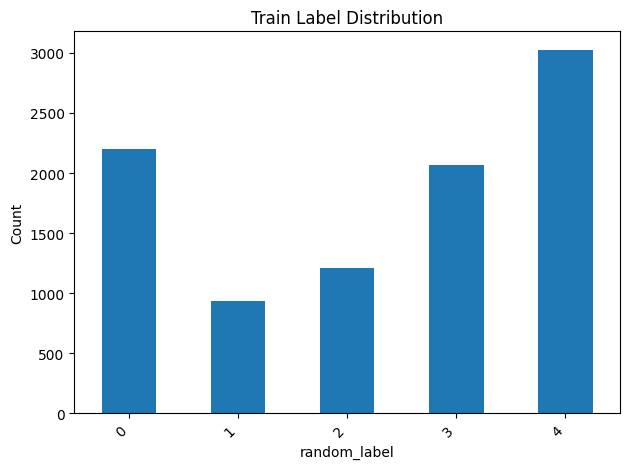

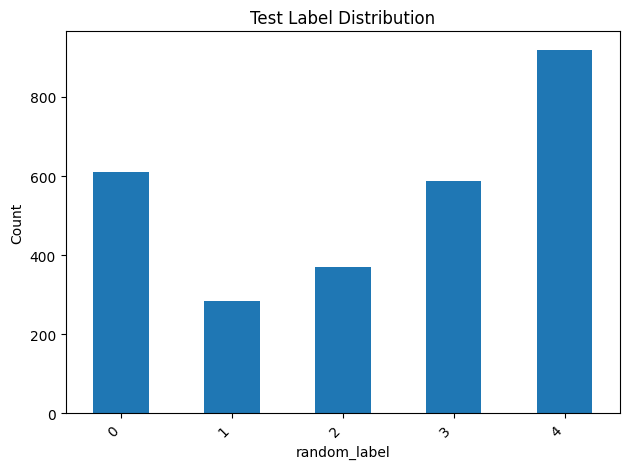

In [ ]:
# Visualizing label distributions
train_counts = train_random["random_label"].value_counts().sort_index()
train_counts.plot(kind="bar", title="Train Label Distribution")
plt.xlabel("random_label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

test_counts = test_random["random_label"].value_counts().sort_index()
test_counts.plot(kind="bar", title="Test Label Distribution")
plt.xlabel("random_label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Data Prep for Models

In [ ]:
train_df_split, val_df_split = train_test_split(
    train_random,
    test_size=0.3,
    random_state=42,
    stratify=train_random["random_label"]
)

train_df_split = train_df_split.reset_index(drop=True)
val_df_split = val_df_split.reset_index(drop=True)

In [ ]:
train_df = train_df_split[["medical_abstract", "random_label"]].rename(columns={
    "medical_abstract": "text",
    "random_label": "label"
})

val_df = val_df_split[["medical_abstract", "random_label"]].rename(columns={
    "medical_abstract": "text",
    "random_label": "label"
})

test_df = test_random[["medical_abstract", "random_label"]].rename(columns={
    "medical_abstract": "text",
    "random_label": "label"
})

## Baseline Model (Logistic Regression)

In [ ]:
def build_log_reg_model(train_df, test_df):
  pipe = Pipeline([
      ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_features=None,
        strip_accents="unicode",
      )),
      ("clf", LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight=None,
        multi_class="multinomial",
        solver="lbfgs",
      ))
  ])

  # train
  pipe.fit(train_df["text"], train_df["label"])

  # predict on val
  y_true = test_df["label"]
  y_pred = pipe.predict(test_df["text"])

  # metrics
  acc = accuracy_score(y_true, y_pred)
  macro_f1 = f1_score(y_true, y_pred, average="macro")

  print("Test accuracy:  {:.4f}".format(acc))
  print("Test macro-F1: {:.4f}".format(macro_f1))
  print()
  print("Per-class report:")
  print(classification_report(y_true, y_pred))

  return pipe, (y_true, y_pred)

In [ ]:
logreg_model, (y_true, y_pred) = build_log_reg_model(train_df, test_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test accuracy:  0.5408
Test macro-F1: 0.5034

Per-class report:
              precision    recall  f1-score   support

           0       0.69      0.72      0.71       611
           1       0.48      0.25      0.33       283
           2       0.56      0.28      0.38       369
           3       0.64      0.61      0.62       587
           4       0.42      0.57      0.49       920

    accuracy                           0.54      2770
   macro avg       0.56      0.49      0.50      2770
weighted avg       0.55      0.54      0.53      2770



## PubMedBERT Model

Step 1: Convert pandas df to 🤗 dataset

In [ ]:
label2id = {
    "Neoplasms": 0,
    "Digestive system diseases": 1,
    "Nervous system diseases": 2,
    "Cardiovascular diseases": 3,
    "General pathological conditions": 4,
}

id2label = {v: k for k, v in label2id.items()}

train_ds = Dataset.from_pandas(train_df[["text","label"]], preserve_index=False)
val_ds   = Dataset.from_pandas(val_df[["text","label"]],   preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[["text","label"]],  preserve_index=False)

Step 2: Select model & tokenizer

In [ ]:
# allenai/scibert_scivocab_uncased
# michiyasunaga/BioLinkBERT-base

model_name = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors='pt'
    )

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

cols = ["input_ids","attention_mask","label"]
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in cols]).with_format("torch")
val_tok   = val_tok.remove_columns([c for c in val_tok.column_names   if c not in cols]).with_format("torch")
test_tok  = test_tok.remove_columns([c for c in test_tok.column_names if c not in cols]).with_format("torch")

Map:   0%|          | 0/6611 [00:00<?, ? examples/s]

Map:   0%|          | 0/2834 [00:00<?, ? examples/s]

Map:   0%|          | 0/2770 [00:00<?, ? examples/s]

Step 3: Metrics !

In [ ]:
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

Step 4: Train BERT model

In [ ]:
training_args = TrainingArguments(
    output_dir="~/266_NLP/Final Project",
    seed=42,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=0.00002,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.927300,0.755780,0.688426,0.679054,0.683746
2,0.573000,0.724219,0.733945,0.731653,0.725771
3,0.441900,0.796008,0.732534,0.731572,0.726656


TrainOutput(global_step=2481, training_loss=0.6125446890016469, metrics={'train_runtime': 1104.1219, 'train_samples_per_second': 17.963, 'train_steps_per_second': 2.247, 'total_flos': 2609211059744256.0, 'train_loss': 0.6125446890016469, 'epoch': 3.0})

Confusion Matrix

In [ ]:
out = trainer.predict(val_tok)
y_true = out.label_ids
y_pred = np.argmax(out.predictions, axis=1)

label_names = ["Neoplasms", "Digestive system diseases", "Nervous system diseases", "Cardiovascular diseases", "General pathological conditions"]

[[598  13   9   6  35]
 [ 14 209   3   5  50]
 [ 15   4 253  20  72]
 [ 15   4  20 511  69]
 [102  66  91 145 505]]


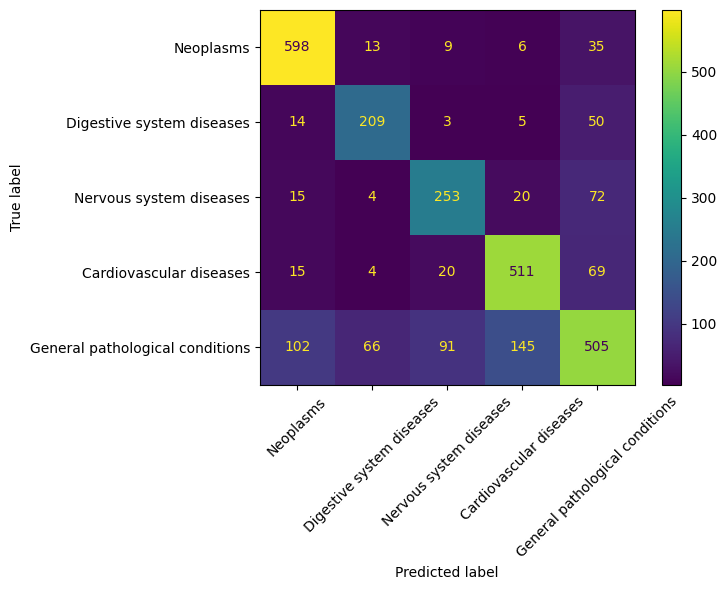

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45)

plt.tight_layout()
plt.show()

Step 5: Final test accuracy

In [ ]:
test_output = trainer.predict(test_tok)

logits = test_output.predictions
y_true_test = test_output.label_ids
y_pred_test = logits.argmax(axis=1)

print(classification_report(y_true_test, y_pred_test, target_names=label_names))

                                 precision    recall  f1-score   support

                      Neoplasms       0.70      0.81      0.75       611
      Digestive system diseases       0.54      0.62      0.58       283
        Nervous system diseases       0.59      0.61      0.60       369
        Cardiovascular diseases       0.68      0.76      0.72       587
General pathological conditions       0.57      0.44      0.50       920

                       accuracy                           0.63      2770
                      macro avg       0.62      0.65      0.63      2770
                   weighted avg       0.62      0.63      0.62      2770



[[492  29  28   9  53]
 [ 34 175   4   6  64]
 [ 28   5 224  29  83]
 [  9   9  19 444 106]
 [140 107 103 164 406]]


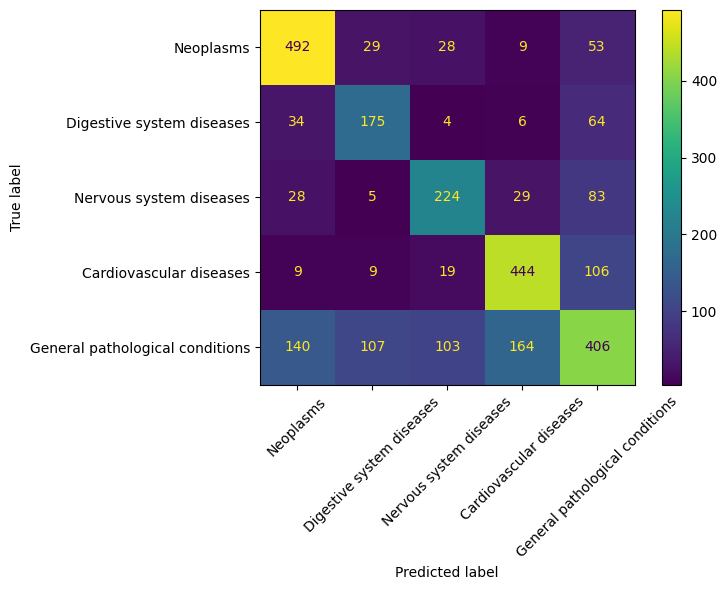

In [ ]:
cm = confusion_matrix(y_true_test, y_pred_test)
print(cm)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45)

plt.tight_layout()
plt.show()

# Drug Review Data

### EDA & Data Cleaning

In [2]:
# -----------------------------
# Imports
# -----------------------------
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score,precision_score, recall_score, f1_score
from transformers import pipeline, DataCollatorWithPadding
from datasets import load_dataset
from openai import OpenAI

import os
from google.colab import userdata

from tqdm import tqdm
from torch.utils.data import DataLoader, WeightedRandomSampler, TensorDataset
import torch

from transformers import set_seed
# from transformers import DataCollatorWithPadding

In [30]:
# -----------------------------
# Load and preprocess dataset
# -----------------------------
ds = load_dataset("Mouwiya/drug-reviews")   # Hugging Face dataset
df = ds["train"].to_pandas().dropna(subset=["review", "rating"])
test_df = ds["test"].to_pandas().dropna(subset=["review", "rating"])

# Collapse ratings into 5 buckets
def collapse_rating(r):
    if r in [1, 2]:
        return 0
    elif r in [3, 4]:
        return 1
    elif r in [5, 6]:
        return 2
    elif r in [7, 8]:
        return 3
    else:
        return 4

df["rating_bucket"] = df["rating"].apply(collapse_rating)
test_df["rating_bucket"] = test_df["rating"].apply(collapse_rating)

# Dictionary for reference
original_label_dict = {
    "0": "1-2 stars",
    "1": "3-4 stars",
    "2": "5-6 stars",
    "3": "7-8 stars",
    "4": "9-10 stars"
}

In [31]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)         # remove HTML tags
    text = re.sub(r"['\"`]", "", text)         # remove quotes
    text = re.sub(r"[^a-z0-9.,!?;:() ]", " ", text)  # remove special characters
    text = re.sub(r"\s+", " ", text).strip()   # normalize whitespace
    return text

In [32]:
df["drugName"] = df["drugName"].apply(clean_text)
df["condition"] = df["condition"].apply(clean_text)
df["review"] = df["review"].apply(clean_text)

test_df["drugName"] = test_df["drugName"].apply(clean_text)
test_df["condition"] = test_df["condition"].apply(clean_text)
test_df["review"] = test_df["review"].apply(clean_text)

In [33]:
print("EDA SUMMARY: ")
print("Dataset shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())

print("\nRating bucket distribution:")
print(df["rating_bucket"].value_counts(normalize=True).round(3))

# Average review length
df["review_length"] = df["review"].apply(lambda x: len(x.split()))
print("\nAverage review length:", df["review_length"].mean())
print("Shortest review length:", df["review_length"].min())
print("Longest review length:", df["review_length"].max())

# Example cleaned text
print("\nSample cleaned review:\n", df["review"].iloc[0][:500], "...")

EDA SUMMARY: 
Dataset shape: (27703, 9)

Missing values per column:
 patient_id       0
drugName         0
condition        0
review           0
rating           0
date             0
usefulCount      0
review_length    0
rating_bucket    0
dtype: int64

Rating bucket distribution:
rating_bucket
4    0.479
3    0.183
0    0.170
2    0.094
1    0.074
Name: proportion, dtype: float64

Average review length: 95.24387250478287
Shortest review length: 28
Longest review length: 1181

Sample cleaned review:
 sober a year 8 25 11. god, aa and campral have worked. no cravings i couldnt handle. together all have helped me have a new lease on life. feel better, work has improved. highly recommend this medicine if you want to quit drinking. ...


In [34]:
print("EDA SUMMARY: ")
print("Test dataset shape:", test_df.shape)
print("\nMissing values per column:\n", test_df.isna().sum())

print("\nTest Rating bucket distribution:")
print(test_df["rating_bucket"].value_counts(normalize=True).round(3))

# Average review length
df["review_length"] = test_df["review"].apply(lambda x: len(x.split()))
print("\nAverage review length:", test_df["review_length"].mean())
print("Shortest review length:", test_df["review_length"].min())
print("Longest review length:", test_df["review_length"].max())

# Example cleaned text
print("\nSample cleaned review:\n", test_df["review"].iloc[0][:500], "...")

EDA SUMMARY: 
Test dataset shape: (46108, 9)

Missing values per column:
 patient_id       0
drugName         0
condition        0
review           0
rating           0
date             0
usefulCount      0
review_length    0
rating_bucket    0
dtype: int64

Test Rating bucket distribution:
rating_bucket
4    0.483
3    0.177
0    0.175
2    0.092
1    0.073
Name: proportion, dtype: float64

Average review length: 95.41515572134988
Shortest review length: 31
Longest review length: 1162

Sample cleaned review:
 ive tried a few antidepressants over the years (citalopram, fluoxetine, amitriptyline), but none of those helped with my depression, insomnia anxiety. my doctor suggested and changed me onto 45mg mirtazapine and this medicine has saved my life. thankfully i have had no side effects especially the most common weight gain, ive actually lost alot of weight. i still have suicidal thoughts but mirtazapine has saved me. ...


### Data Prep for Models

In [35]:
df["text"] = df["drugName"].astype(str) + " | " + df["condition"].astype(str) + " | " + df["review"].astype(str)
# df["text"] = df["review"].astype(str)
y = df["rating_bucket"].values

test_df["text"] = test_df["drugName"].astype(str) + " | " + test_df["condition"].astype(str) + " | " + test_df["review"].astype(str)
y_test = test_df["rating_bucket"].values

In [40]:
# Stratified Split
train_df, val_df, y_train, y_val = train_test_split(
    df["text"], y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train df shape: {train_df.shape[0]}')
print(f'Train example: {train_df.iloc[0]}')

print(f'Val df shape: {val_df.shape[0]}')
print(f'Val example: {val_df.iloc[0]}')

print(f'Test df shape: {test_df["text"].shape[0]}')
print(f'Test example: {test_df["text"].iloc[0]}')

Train df shape: 22162
Train example: zoloft | panic disorde | i have taken 25mg for anxiety for 8 years. i went off when pregnant but anxiety returned upon delivery. i can not say enough how much this drug has helped me. i dont do the whole i want to feel good on my own thing anymore. i accept that i will always have anxiety but with zoloft i live a normal life now. if i have a health scare and it comes on a bit i can still cope so much better now. i am so thankful for zoloft.
Val df shape: 5541
Val example: amoxicillin clavulanate | skin or soft tissue infection | this med was given as a result of a deep gouge from a dog nail. healing was not occurring after 4 weeks including a trip to a ambulatory care. my doc said they treated it incorrectly. he prescribed this. i have an appointment at the wound center tues. dr also said it needed debriding. after 5 days i see no improvement. if anything the area is more red and sore.
Test df shape: 46108
Test example: mirtazapine | depression | iv

### PubMedBERT Model

In [43]:
train_df = pd.DataFrame({"text": train_df, "label": y_train})
val_df   = pd.DataFrame({"text": val_df,   "label": y_val})
test_df   = pd.DataFrame({"text": test_df["text"],   "label": y_test})

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)

In [10]:
# allenai/scibert_scivocab_uncased
# michiyasunaga/BioLinkBERT-base

model_name = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [44]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=512,
    )

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)
test_tok = test_ds.map(tokenize, batched=True)

cols = ["input_ids","attention_mask","label"]
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in cols]).with_format("torch")
val_tok   = val_tok.remove_columns([c for c in val_tok.column_names   if c not in cols]).with_format("torch")
test_tok   = test_tok.remove_columns([c for c in test_tok.column_names   if c not in cols]).with_format("torch")

Map:   0%|          | 0/22162 [00:00<?, ? examples/s]

Map:   0%|          | 0/5541 [00:00<?, ? examples/s]

Map:   0%|          | 0/46108 [00:00<?, ? examples/s]

In [13]:
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

In [14]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
set_seed(42)

training_args = TrainingArguments(
    output_dir="~/266_NLP/Final Project",
    seed=42,
    num_train_epochs=5,
    learning_rate=0.00002,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,
    fp16=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.906100,0.876691,0.652770,0.422288,0.598915
2,0.802800,0.867264,0.663779,0.509960,0.648627
3,0.677400,0.915706,0.665223,0.531926,0.662418
4,0.545500,1.000317,0.670637,0.519541,0.656303
5,0.446800,1.152537,0.663418,0.542914,0.664682


TrainOutput(global_step=13855, training_loss=0.6957219553699308, metrics={'train_runtime': 1792.4295, 'train_samples_per_second': 61.821, 'train_steps_per_second': 7.73, 'total_flos': 1.0654209631004364e+16, 'train_loss': 0.6957219553699308, 'epoch': 5.0})

In [15]:
out = trainer.predict(val_tok)
y_true = out.label_ids
y_pred = np.argmax(out.predictions, axis=1)

label_names = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]

[[ 660  126   94   37   23]
 [ 115  140   84   49   21]
 [  64   88  196  142   33]
 [  24   51  115  459  365]
 [  22   11   49  352 2221]]


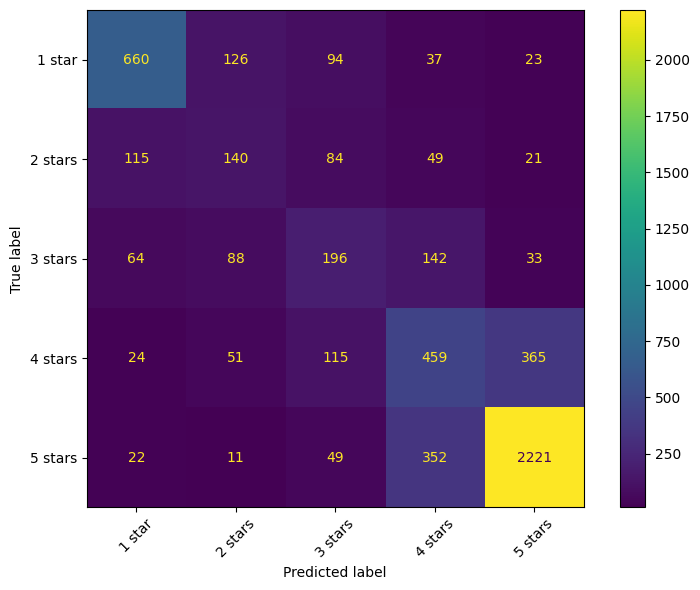

In [16]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45)

plt.tight_layout()
plt.show()

In [45]:
test_output = trainer.predict(test_tok)

logits = test_output.predictions
y_true_test = test_output.label_ids
y_pred_test = logits.argmax(axis=1)

print(classification_report(y_true_test, y_pred_test, target_names=label_names))

              precision    recall  f1-score   support

      1 star       0.75      0.72      0.73      8062
     2 stars       0.32      0.30      0.31      3383
     3 stars       0.34      0.36      0.35      4254
     4 stars       0.43      0.44      0.44      8161
     5 stars       0.83      0.83      0.83     22248

    accuracy                           0.66     46108
   macro avg       0.53      0.53      0.53     46108
weighted avg       0.66      0.66      0.66     46108



# Mental Health Data

### EDA & Data Cleaning

In [ ]:
from datasets import load_dataset, Dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.utils import resample

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Error: File not found at /content/drive/MyDrive/266_NLP/Final_Project/Mental_Health/train_balanced.csv


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/266_NLP/Final_Project/Mental_Health/train_balanced.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/266_NLP/Final_Project/Mental_Health/val.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/266_NLP/Final_Project/Mental_Health/test.csv")

In [ ]:
train_df.head()

,statement,status,status_combined
0,"Hi everybody, I'm a 22 year old male who has h...",Stress,Anxiety/Stress
1,TL;DR: I wish to ask out my longtime friend th...,Stress,Anxiety/Stress
2,@sophistifunk aye,Normal,Normal
3,A possible blood clot? I know that I suffer fr...,Anxiety,Anxiety/Stress
4,three pounds just this month.,Normal,Normal


In [ ]:
# Define the label mapping
label2id = {
    "Depressive_Spectrum": 0,
    "Bipolar/Personality": 1,
    "Anxiety/Stress": 2,
    "Normal": 3,
}

id2label = {v: k for k, v in label2id.items()}

In [ ]:
train_df = train_df[["statement", "status_combined"]].rename(columns={
    "statement": "text",
    "status_combined": "label"
})

val_df = val_df[["statement", "status_combined"]].rename(columns={
    "statement": "text",
    "status_combined": "label"
})

test_df = test_df[["statement", "status_combined"]].rename(columns={
    "statement": "text",
    "status_combined": "label"
})

KeyError: "None of [Index(['statement', 'status_combined'], dtype='object')] are in the [columns]"

In [ ]:
train_df["label"] = train_df["label"].map(label2id)
val_df["label"]   = val_df["label"].map(label2id)
test_df["label"]  = test_df["label"].map(label2id)

In [ ]:
train_df["text"] = train_df["text"].astype(str)
val_df["text"]   = val_df["text"].astype(str)
test_df["text"]  = test_df["text"].astype(str)

### PubMedBERT Model

In [ ]:
train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds   = Dataset.from_pandas(val_df, preserve_index=False)
test_ds  = Dataset.from_pandas(test_df, preserve_index=False)

In [ ]:
# allenai/scibert_scivocab_uncased
# michiyasunaga/BioLinkBERT-base

model_name = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=512,
    )

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

cols = ["input_ids","attention_mask","label"]
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in cols]).with_format("torch")
val_tok   = val_tok.remove_columns([c for c in val_tok.column_names   if c not in cols]).with_format("torch")
test_tok  = test_tok.remove_columns([c for c in test_tok.column_names if c not in cols]).with_format("torch")

Map:   0%|          | 0/44914 [00:00<?, ? examples/s]

Map:   0%|          | 0/9625 [00:00<?, ? examples/s]

Map:   0%|          | 0/9625 [00:00<?, ? examples/s]

In [ ]:
train_tok[0]

{'label': tensor(2),
 'input_ids': tensor([    2, 10220,  4808, 19665,    16,    51,    11,    55,    43,  2950,
          2476,  4156,  4005,  2746,  2258,  2430,  9848,  4621,  1930,  5592,
          6384,  3328,    51,  1982,  2369,  2739,  4156,    18,    51,  1982,
          2222,    43, 10362, 12283,  9213,  6552,  2353,  1930,  2144,  6384,
          8074,  2300,  6539,  2353,  2469,    51,  1982, 12772,  2460,  1925,
          2632,  2210,  1956,    43,  3345,  9610,  1930, 19736,  2671,    18,
            21,    18,    25,  6231, 15781,  7544,    12,    24,  1040, 26169,
          8544,  1036,    13,    26,  3000,    43,  2982,  1956,    43,  2627,
          8623,  7143,  4702,  4695, 16623,  2014,  4808,  2303,  3007,    16,
            51,  9129,    18,    51,  2430,  3476,  1976, 21892,  2340,  9572,
          3119, 16348,  5396,  2460,  2052,  2210,  1930,  1982,  5796, 18557,
          2947,    18,     3]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
set_seed(42)

training_args = TrainingArguments(
    output_dir="~/266_NLP/Final Project",
    seed=42,
    num_train_epochs=2,
    learning_rate=0.00002,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,
    fp16=True,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.224300,0.176482,0.947532,0.947484,0.947484
2,0.128400,0.184714,0.956156,0.956107,0.956106


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.224300,0.176482,0.947532,0.947484,0.947484
2,0.128400,0.184714,0.956156,0.956107,0.956106
3,0.074400,0.151179,0.971532,0.971493,0.971493


KeyboardInterrupt: 

In [ ]:
out = trainer.predict(val_tok)
y_true = out.label_ids
y_pred = np.argmax(out.predictions, axis=1)

labels = [id2label[i] for i in range(len(id2label))]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.224300,0.176482,0.947532,0.947484,0.947484
2,0.128400,0.184714,0.956156,0.956107,0.956106
3,0.074400,0.151179,0.971532,0.971493,0.971493


[[2272   50   47   38]
 [   2 2398    6    0]
 [  20   22 2354   10]
 [  32    5   65 2304]]


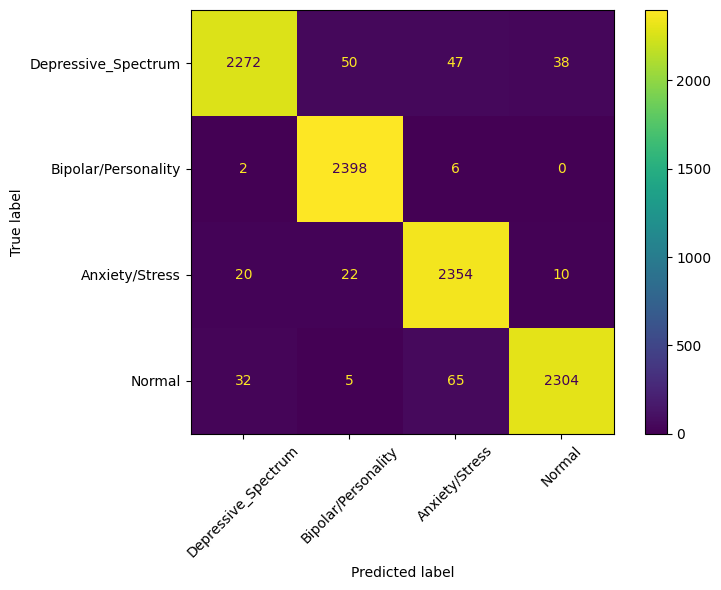

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
test_output = trainer.predict(test_tok)

logits = test_output.predictions
y_true_test = test_output.label_ids
y_pred_test = logits.argmax(axis=1)

print(classification_report(y_true_test, y_pred_test, target_names=labels))

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.224300,0.176482,0.947532,0.947484,0.947484
2,0.128400,0.184714,0.956156,0.956107,0.956106
3,0.074400,0.151179,0.971532,0.971493,0.971493


                     precision    recall  f1-score   support

Depressive_Spectrum       0.98      0.95      0.96      2406
Bipolar/Personality       0.96      0.99      0.98      2406
     Anxiety/Stress       0.96      0.97      0.96      2407
             Normal       0.97      0.96      0.97      2406

           accuracy                           0.97      9625
          macro avg       0.97      0.97      0.97      9625
       weighted avg       0.97      0.97      0.97      9625



#